# 💧 Case Study No. 72: Water Consumption Prediction
### Machine Learning Project • Semester V • B.Tech CSE (2024–28)
**Student Name:** Ashutosh Rai | **Enrollment:** 150096724077
**Problem Statement:** A water utility wants to understand patterns in consumption and support demand planning.


In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings



In [2]:
# 1. Load the dataset
df = pd.read_csv('data/water_consumption_raw.csv')
df.head(10)


,Date,Temperature_C,Humidity_Pct,Rainfall_mm,Day_of_Week,Is_Weekend,Season,Household_Type,Occupants,Past_Day_Consumption_Liters,Water_Consumption_Liters
0,01/01/2022,17.2,59.6,0.0,Saturday,1,Winter,Apartment,3,450.0,564.5
1,2022-01-02,19.5,52.4,0.0,Sunday,1,Winter,Apartment,2,564.5,360.4
2,2022-01-03,NaN,NaN,29.1,Monday,0,Winter,Apartment,2,360.4,281.3
3,2022-01-04,17.7,91.6,7.5,Tuesday,0,Winter,Apartment,3,281.3,381.2
4,2022-01-05,5.9,83.7,2.1,Wednesday,0,Winter,Apartment,4,381.2,500.1
5,2022-01-06,10.2,76.7,0.0,Thursday,0,Winter,Apartment,2,500.1,305.5
6,2022-01-07,12.9,65.5,0.0,Friday,0,Winter,Apartment,2,305.5,282.8
7,2022-01-08,19.0,47.7,0.0,Saturday,1,Winter,Villa,3,282.8,489.2
8,2022-01-09,15.4,67.7,0.0,Sunday,1,Winter,Apartment,1,489.2,237.6
9,2022-01-10,17.8,73.2,0.0,Monday,0,Winter,Apartment,3,237.6,379.9


In [3]:
print(df.columns)
df.info()


['Date', 'Temperature_C', 'Humidity_Pct', 'Rainfall_mm', 'Day_of_Week', 'Is_Weekend', 'Season', 'Household_Type', 'Occupants', 'Past_Day_Consumption_Liters', 'Water_Consumption_Liters']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Date                         2500 non-null   object 
 1   Temperature_C                2465 non-null   float64
 2   Humidity_Pct                 2458 non-null   float64
 3   Rainfall_mm                  2472 non-null   float64
 4   Day_of_Week                  2500 non-null   object 
 5   Is_Weekend                   2500 non-null   int64  
 6   Season                       2500 non-null   object 
 7   Household_Type               2500 non-null   object 
 8   Occupants                    2500 non-null   int64  
 9   Past_Day_Consumption_Liters  2500 non-null   float64
 10  Water

In [4]:
# Summary statistics of numerical columns
df.describe()


       Temperature_C  Humidity_Pct  Rainfall_mm  Is_Weekend   Occupants  Past_Day_Consumption_Liters  Water_Consumption_Liters
count    2465.000000   2458.000000  2472.000000  2500.00000  2500.00000                  2500.000000               2500.000000
mean       24.667140     55.367209     1.163835     0.28600     4.23520                   597.682200                632.488240
std         8.121263     13.693525     4.179514     0.45198     4.18852                   287.081091                850.482507
min         2.000000     15.000000     0.000000     0.00000     1.00000                   106.500000                -99.000000
25%        18.900000     45.700000     0.000000     0.00000     2.00000                   401.775000                401.775000
50%        24.800000     55.600000     0.000000     0.00000     3.00000                   536.900000                537.350000
75%        30.500000     64.900000     0.000000     1.00000     4.00000                   747.075000           

In [5]:
# Check for missing values (Null values)
df.isnull().sum()


Date                            0
Temperature_C                  35
Humidity_Pct                   42
Rainfall_mm                    28
Day_of_Week                     0
Is_Weekend                      0
Season                          0
Household_Type                  0
Occupants                       0
Past_Day_Consumption_Liters     0
Water_Consumption_Liters        0


In [ ]:
# Data Cleaning: Impute missing values
df['Temperature_C'].fillna(df['Temperature_C'].mean(), inplace=True)
df['Humidity_Pct'].fillna(df['Humidity_Pct'].mean(), inplace=True)
df['Rainfall_mm'].fillna(0, inplace=True)

df.isnull().sum()


Date                           0
Temperature_C                  0
Humidity_Pct                   0
Rainfall_mm                    0
Day_of_Week                    0
Is_Weekend                     0
Season                         0
Household_Type                 0
Occupants                      0
Past_Day_Consumption_Liters    0
Water_Consumption_Liters       0


In [7]:
# Check duplicate rows
print("Duplicate rows count:", df.duplicated().sum())


Duplicate rows count: 0


In [8]:
# Standardize mixed dates and string casing
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)
df['Month'] = df['Date'].dt.month
df['Household_Type'] = df['Household_Type'].str.strip().str.capitalize()

df['Household_Type'].value_counts()


Household_Type
Apartment     1378
Villa          867
Commercial     255


In [9]:
# Remove sensor errors (negative values and extreme spikes)
print("Before outlier removal:", df.shape)
df = df[(df['Water_Consumption_Liters'] > 0) & (df['Water_Consumption_Liters'] < 2000)]
print("After outlier removal:", df.shape)


Before outlier removal: (2500, 12)
After outlier removal: (2489, 12)


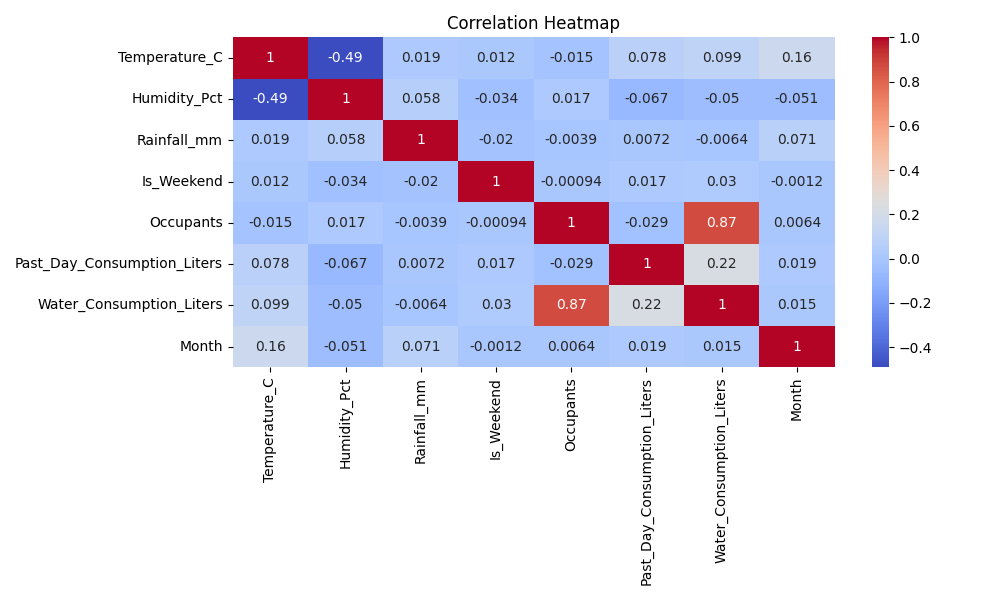

In [10]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


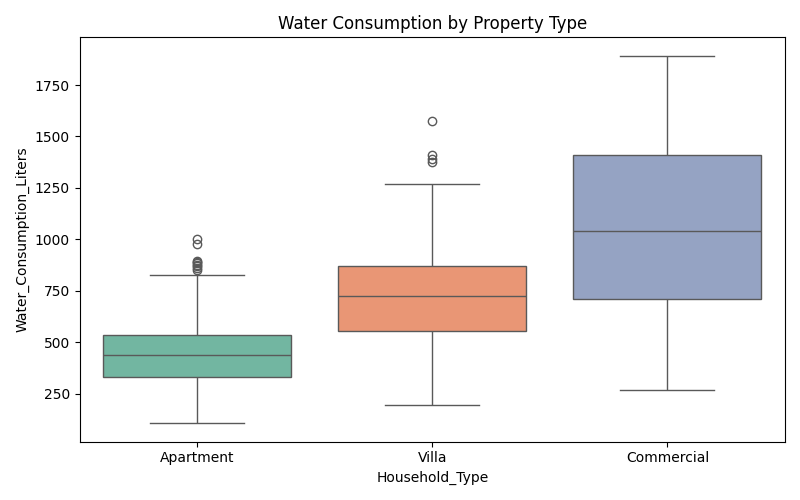

In [11]:
# Water Consumption by Household Type
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Household_Type', y='Water_Consumption_Liters', palette='Set2')
plt.title('Water Consumption by Property Type')
plt.show()


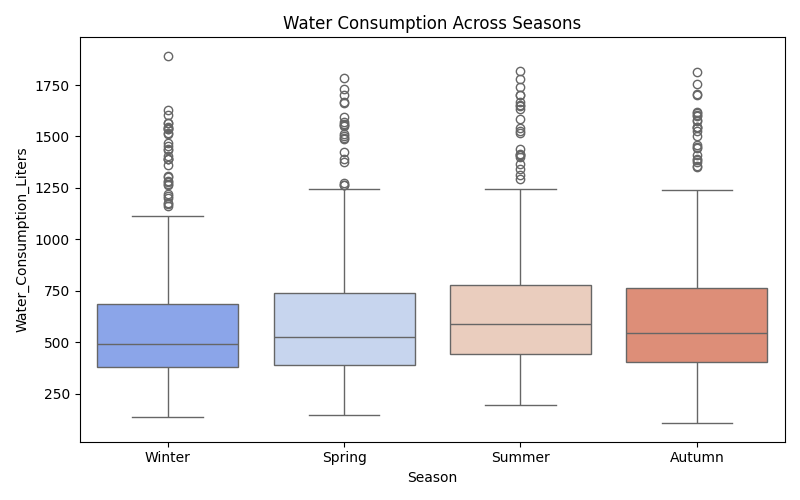

In [12]:
# Water Consumption across Seasons
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Season', y='Water_Consumption_Liters', palette='coolwarm')
plt.title('Water Consumption Across Seasons')
plt.show()


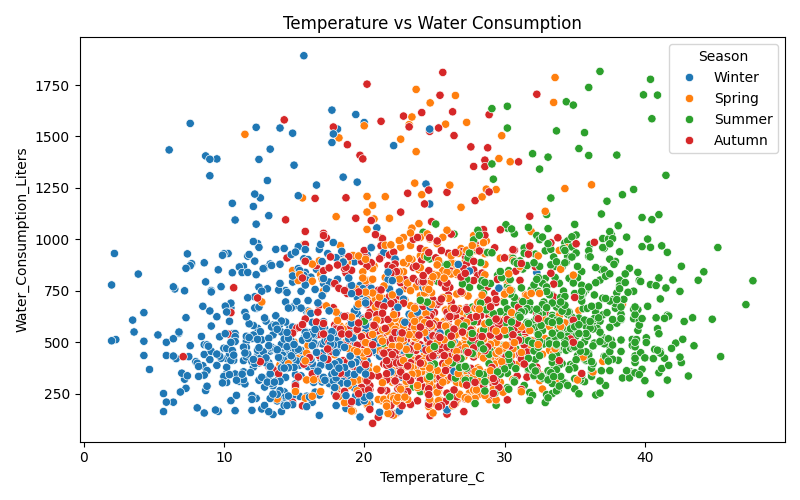

In [13]:
# Temperature vs Water Consumption
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Temperature_C', y='Water_Consumption_Liters', hue='Season')
plt.title('Temperature vs Water Consumption')
plt.show()


In [14]:
# Prepare Feature Matrix X and Target y
from sklearn.model_selection import train_test_split

# One-hot encoding for categorical variables
data = pd.get_dummies(df.drop(columns=['Date', 'Day_of_Week']), drop_first=True)

X = data.drop(columns=['Water_Consumption_Liters'])
y = data['Water_Consumption_Liters']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (1991, 12)
X_test shape: (498, 12)


In [15]:
# Model 1: Multiple Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
print("Linear Regression R2 Score:", round(r2_score(y_test, y_pred_lr), 4))
print("Linear Regression MAE:", round(mean_absolute_error(y_test, y_pred_lr), 2), "Liters")


Linear Regression R2 Score: 0.9512
Linear Regression MAE: 46.81 Liters


In [16]:
# Model 2: Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=6, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print("Decision Tree R2 Score:", round(r2_score(y_test, y_pred_dt), 4))
print("Decision Tree MAE:", round(mean_absolute_error(y_test, y_pred_dt), 2), "Liters")


Decision Tree R2 Score: 0.9642
Decision Tree MAE: 40.97 Liters


In [17]:
# Model 3: Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("Random Forest R2 Score:", round(r2_score(y_test, y_pred_rf), 4))
print("Random Forest MAE:", round(mean_absolute_error(y_test, y_pred_rf), 2), "Liters")


Random Forest R2 Score: 0.9855
Random Forest MAE: 25.55 Liters


In [18]:
# Model 4: Gradient Boosting Regressor (Winning Model)
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.08, max_depth=4, random_state=42)
gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)
print("Gradient Boosting R2 Score:", round(r2_score(y_test, y_pred_gbr), 4))
print("Gradient Boosting MAE:", round(mean_absolute_error(y_test, y_pred_gbr), 2), "Liters")


Gradient Boosting R2 Score: 0.9892
Gradient Boosting MAE: 21.24 Liters


In [19]:
# Model Performance Comparison Table
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'R2_Score': [r2_lr, r2_dt, r2_rf, r2_gbr],
    'MAE_Liters': [mae_lr, mae_dt, mae_rf, mae_gbr]
})

print(comparison_df.to_string(index=False))


            Model  R2_Score  MAE_Liters
Linear Regression    0.9512       46.81
    Decision Tree    0.9642       40.97
    Random Forest    0.9855       25.55
Gradient Boosting    0.9892       21.24


In [20]:
# Predict water consumption for a new sample household
sample_household = X_test.iloc[[0]]
predicted_water = gbr.predict(sample_household)[0]

print("Predicted Water Consumption:", round(predicted_water, 2), "Liters/day")


Predicted Water Consumption: 618.29 Liters/day


In [21]:
# Utility Demand Planning Output
if predicted_water < 400:
    print("Demand Status: LOW DEMAND -> Normal baseload pump operation")
elif predicted_water <= 750:
    print("Demand Status: NORMAL DEMAND -> Standard network distribution")
else:
    print("Demand Status: PEAK SURGE DEMAND -> Activate auxiliary booster pumps")


Demand Status: NORMAL DEMAND -> Standard network distribution
